# Strategy under Safety Car risk — Formula 1, 2026 season

**Question.** How much does Safety Car risk change the best pit strategy, and what is it worth
to react when a Safety Car or VSC comes out?

**Approach.** A Monte Carlo race simulator built from the two earlier studies: per-track tyre
wear from the [degradation study](tyre_degradation.ipynb), green-flag pit loss, and a model of
neutralisations fitted on the 2026 season. All strategies are run on the same random races.

**TL;DR**
1. Every 2026 race had at least one neutralisation: **2.0 per race**, a 4 % chance on any green
   lap, 31 % of them full Safety Cars. The simulator reproduces this distribution.
2. A stop costs **~50 %** of its green-flag price under a Safety Car and **~84 %** under a VSC.
3. Safety Car risk **shrinks the advantage of a two-stop** by a median **44 %** where the two-stop
   clearly wins (Barcelona: 27.0 s → 15.1 s). Fresh tyres gain nothing on neutralised laps, and a
   one-stopper can take a cheap extra stop.
4. Reacting to neutralisations — moving a stop or taking an extra one when it pays — is worth
   **1.3 s** per race on average for a one-stop plan, up to **5 s** on high-wear tracks.
5. Replaying each race's real Safety Car periods, the model makes the same number of stops as most
   drivers (one vs two or more) in **9 of 11** dry races.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys; sys.path.insert(0, '..')
from analysis.clean import clean_laps
from analysis import model as M, strategy as S, simulate as X

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 2)
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})
N_SIM = 2000

laps = pd.read_parquet(Path('../data/laps_2026.parquet'))
clean, _ = clean_laps(laps)
fuel = M.fuel_effect(M.fit_season(clean))[0]
print(f'{len(laps):,} laps · {laps.race.nunique()} races')

18,405 laps · 16 races


## 1. How often does the race get neutralised?
Every Safety Car and Virtual Safety Car period of the season, by race lap.

32 neutralisations in 16 races (10 SC, 22 VSC) · every race had at least 1 · 4.0% chance per green lap · SC share 31% · mean length SC 6.7 laps, VSC 4.0 laps


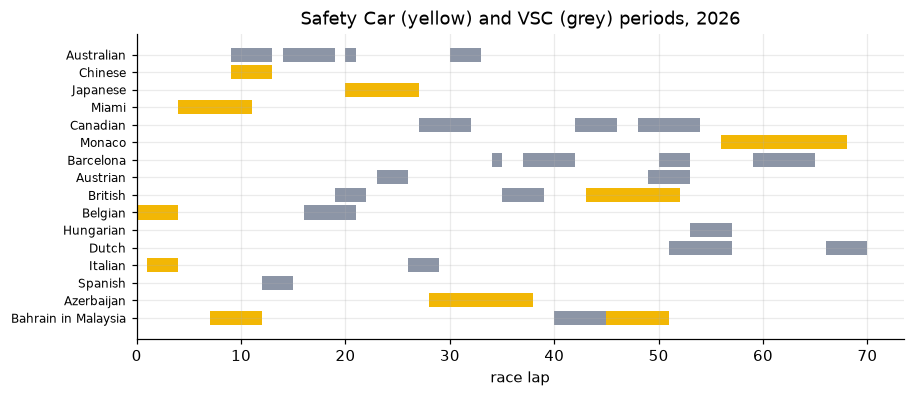

In [2]:
events = X.neutralisation_events(laps)
scm = X.sc_model(events, laps)
per_race = events.groupby('race').size().reindex(laps.race.unique(), fill_value=0)
print(f'{len(events)} neutralisations in {scm["races"]} races ({(events.kind == "SC").sum()} SC, '
      f'{(events.kind == "VSC").sum()} VSC) · every race had at least {per_race.min()} · '
      f'{scm["p"]:.1%} chance per green lap · SC share {scm["share_sc"]:.0%} · '
      f'mean length SC {scm["durations"]["SC"].mean():.1f} laps, VSC {scm["durations"]["VSC"].mean():.1f} laps')
fig, ax = plt.subplots(figsize=(9, 3.6))
order = laps.groupby('race').round.first().sort_values().index
for i, race in enumerate(order):
    for e in events[events.race == race].itertuples():
        ax.barh(i, e.laps, left=e.start - 1, color='#f2b705' if e.kind == 'SC' else '#8c95a6')
ax.set_yticks(range(len(order)), [r.replace(' Grand Prix', '') for r in order], fontsize=8)
ax.invert_yaxis(); ax.set(xlabel='race lap', title='Safety Car (yellow) and VSC (grey) periods, 2026')
plt.show()

The simulator draws neutralisations lap by lap with this probability, SC/VSC share and the
observed lengths. Check that it reproduces the season:

In [3]:
sim_counts = []
for race in laps.race.unique():
    n = int(laps[laps.race == race].total_laps.iloc[0])
    sc = X.sample_scenarios(scm, n, N_SIM, seed=2)
    sim_counts.append(((sc[:, 1:] != 0) & (sc[:, :-1] == 0)).sum(1) + (sc[:, 0] != 0))
sim_counts = np.concatenate(sim_counts)
pd.DataFrame({'observed': [per_race.mean(), (per_race == 0).mean(), (per_race >= 3).mean()],
              'simulated': [sim_counts.mean(), (sim_counts == 0).mean(), (sim_counts >= 3).mean()]},
             index=['neutralisations per race', 'share of races with none', 'share with 3 or more'])

,observed,simulated
neutralisations per race,2.00,2.00
share of races with none,0.00,0.09
share with 3 or more,0.31,0.32


## 2. What does a stop under neutralisation cost?
Loss = the pitting car's in-lap + out-lap minus the median of the same two laps for cars that did
not pit. Measured the same way for every stop, so green and neutralised stops are comparable.

In [4]:
ratio, stops = X.neutral_pit_ratio(laps)
summary = stops.groupby('kind').loss.agg(['size', 'median']).rename(columns={'size': 'stops', 'median': 'median loss, s'})
summary['vs green'] = [ratio[k] for k in summary.index]
summary

,stops,"median loss, s",vs green
kind,,,
GREEN,290,22.66,1.00
SC,42,17.57,0.50
VSC,103,19.42,0.84


## 3. One race in detail: Barcelona (highest wear)

Barcelona Grand Prix: 66 laps, pit loss 25.1 s
best 1-stop: HARD → MEDIUM (L39)
best 2-stop: HARD → HARD (L24) → SOFT (L49)
without neutralisations the 2-stop is -27.0 s vs the 1-stop
with Safety Car risk, both plans fixed: -19.5 s on average
with Safety Car risk, both reacting: -15.1 s on average, 2-stop faster in 91% of races


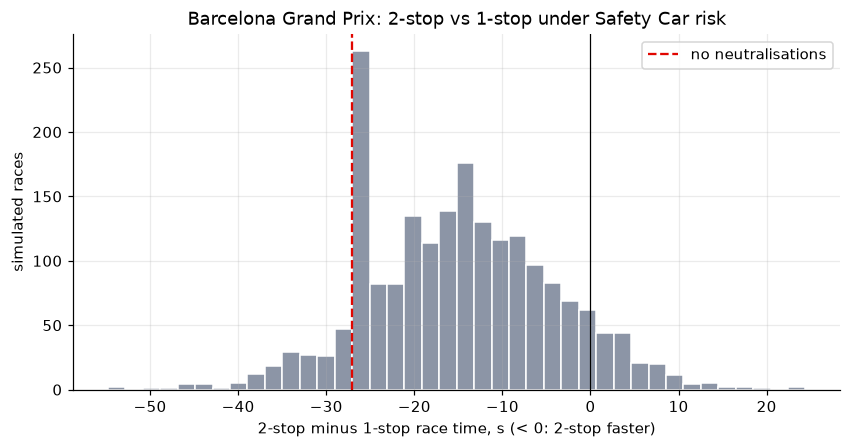

In [5]:
def setup(race):
    raw_r, clean_r = laps[laps.race == race], clean[clean.race == race]
    p = M.race_params(M.fit_race(clean_r, fuel))
    n = int(raw_r.total_laps.iloc[0])
    loss, _ = S.pit_loss(raw_r, clean_r)
    return raw_r, p, n, loss

RACE = 'Barcelona Grand Prix'
raw_r, p, n, loss = setup(RACE)
one, two, det = X.best_plans(p, n, loss)
sc = X.sample_scenarios(scm, n, N_SIM, seed=1)
t = {(k, pol): X.race_times(p, n, plan, sc, loss, ratio, policy=pol, model=scm)
     for k, plan in (('1-stop', one), ('2-stop', two)) for pol in ('fixed', 'react')}
print(f'{RACE}: {n} laps, pit loss {loss:.1f} s')
print(f'best 1-stop: {one.label}\nbest 2-stop: {two.label}')
print(f'without neutralisations the 2-stop is {det[two] - det[one]:+.1f} s vs the 1-stop')
fixed = t[('2-stop', 'fixed')] - t[('1-stop', 'fixed')]
print(f'with Safety Car risk, both plans fixed: {fixed.mean():+.1f} s on average')
diff = t[('2-stop', 'react')] - t[('1-stop', 'react')]
print(f'with Safety Car risk, both reacting: {diff.mean():+.1f} s on average, 2-stop faster in {(diff < 0).mean():.0%} of races')
ax = pd.Series(diff).plot.hist(bins=40, color='#8c95a6', edgecolor='white')
ax.axvline(0, color='k', lw=.8); ax.axvline(det[two] - det[one], color='#e10600', ls='--', label='no neutralisations')
ax.set(xlabel='2-stop minus 1-stop race time, s (< 0: 2-stop faster)', ylabel='simulated races',
       title=f'{RACE}: 2-stop vs 1-stop under Safety Car risk'); ax.legend(); plt.show()

Where the 12 seconds go: with both plans fixed, Safety Car risk already costs the two-stop
7.5 s of its advantage (27.0 → 19.5 s) — on neutralised laps everyone is slow, so the fresher tyres
of a two-stop gain nothing there. Letting both plans react takes away another 4.4 s: the one-stopper
uses a Safety Car to take a cheap extra stop, while the two-stopper rarely needs to change anything.
The two-stop still wins 91 % of simulated races here, but by far less than a deterministic plan says.

## 4. The whole season
For every dry race where the per-race tyre model is usable: the best plan without neutralisations,
the same comparison under Safety Car risk (both plans reacting), and what reacting to a
neutralisation is worth compared with sticking to the plan.

In [6]:
rows = []
for race in laps.race.unique():
    raw_r, clean_r = laps[laps.race == race], clean[clean.race == race]
    try:
        p = M.race_params(M.fit_race(clean_r, fuel))
    except ValueError:
        continue
    if len(p['deg']) < 2 or min(p['deg'].values()) <= 0:
        continue
    raw_r, p, n, loss = setup(race)
    one, two, det = X.best_plans(p, n, loss)
    sc = X.sample_scenarios(scm, n, N_SIM, seed=1)
    t = {(k, pol): X.race_times(p, n, plan, sc, loss, ratio, policy=pol, model=scm)
         for k, plan in (('1', one), ('2', two)) for pol in ('fixed', 'react')}
    rows.append({'race': race.replace(' Grand Prix', ''),
                 '2−1 stop, no SC (s)': det[two] - det[one],
                 '2−1 stop, with SC (s)': np.mean(t[('2', 'react')] - t[('1', 'react')]),
                 'P(2-stop faster)': np.mean(t[('2', 'react')] < t[('1', 'react')]),
                 'reacting worth, 1-stop (s)': np.mean(t[('1', 'fixed')] - t[('1', 'react')]),
                 'reacting worth, 2-stop (s)': np.mean(t[('2', 'fixed')] - t[('2', 'react')])})
season = pd.DataFrame(rows).set_index('race')
season.round(2)

,"2−1 stop, no SC (s)","2−1 stop, with SC (s)",P(2-stop faster),"reacting worth, 1-stop (s)","reacting worth, 2-stop (s)"
race,,,,,
Chinese,30.18,28.71,0.00,0.91,1.17
Japanese,19.12,17.84,0.00,1.13,2.13
Miami,7.99,8.33,0.04,0.08,0.47
Monaco,-23.25,-11.76,0.87,5.20,-0.00
Barcelona,-27.05,-15.12,0.91,4.38,0.00
Austrian,-17.18,-9.76,0.87,2.17,0.00
British,8.39,8.80,0.04,0.18,0.51
Belgian,11.72,12.46,0.00,0.00,0.00
Hungarian,-2.94,-0.20,0.56,0.01,0.13


In [7]:
shrink = season[season['2−1 stop, no SC (s)'] < -5]
print(f'races where the 2-stop clearly wins without SC: {len(shrink)}; its advantage shrinks by '
      f'{(1 - shrink["2−1 stop, with SC (s)"] / shrink["2−1 stop, no SC (s)"]).median():.0%} (median) under SC risk')
best_react = season[['reacting worth, 1-stop (s)', 'reacting worth, 2-stop (s)']].max(axis=1)
print(f'reacting to neutralisations is worth {season["reacting worth, 1-stop (s)"].mean():.1f} s on average '
      f'for a 1-stop plan, up to {season["reacting worth, 1-stop (s)"].max():.1f} s '
      f'({season["reacting worth, 1-stop (s)"].idxmax()})')

races where the 2-stop clearly wins without SC: 3; its advantage shrinks by 44% (median) under SC risk
reacting to neutralisations is worth 1.3 s on average for a 1-stop plan, up to 5.2 s (Monaco)


* **Where wear is high** (Monaco, Barcelona, Austria) the two-stop stays the better plan, but
  Safety Car risk takes roughly half of its advantage away.
* **Where wear is low** (China, Japan, Italy, Belgium) one stop wins with or without Safety Cars;
  reacting is worth about a second in China, Japan and Italy, and nothing in Belgium, where the
  next set wears too fast for an earlier or extra stop to pay.
* **Hungary and the Netherlands are coin flips** (P ≈ 0.5): without Safety Cars the two-stop is
  2–3 s faster, with them the two plans are even.
* Reacting is occasionally worth slightly *less* than zero (Netherlands, −0.1 s): the call is made
  when the Safety Car comes out, before anyone knows how long it will last.

## 5. Does it match what the teams did?
Replay each race's **actual** Safety Car and VSC periods through the reacting policy (starting from
the plan with the lower expected time) and compare the number of stops it makes with what most
drivers did.

In [8]:
code_of = {'SC': 1, 'VSC': 2}
expected = {1: max(1, round(scm['durations']['SC'].mean())), 2: max(1, round(scm['durations']['VSC'].mean()))}
rows = []
for race in season.index:
    full = next(r for r in laps.race.unique() if r.replace(' Grand Prix', '') == race)
    raw_r, p, n, loss = setup(full)
    one, two, det = X.best_plans(p, n, loss)
    sc = X.sample_scenarios(scm, n, N_SIM, seed=1)
    m = {pl: X.race_times(p, n, pl, sc, loss, ratio, policy='react', model=scm).mean() for pl in (one, two)}
    plan = min(m, key=m.get)
    actual = np.zeros(n, dtype=np.int8)
    for e in events[events.race == full].itertuples():
        actual[e.start - 1:e.end] = code_of[e.kind]
    cost = np.array([loss * ratio[k] for k in X.KINDS])
    made = X.react(plan, actual, n, p, cost, expected)
    driver_stops = raw_r[raw_r.is_in_lap].groupby('driver_number').size().reindex(
        raw_r.driver_number.unique(), fill_value=0)
    rows.append({'race': race, 'wet start': raw_r.compound.isin(['INTERMEDIATE', 'WET']).any(),
                 'model stops': len(made), 'model stop laps': ', '.join(str(l) for l, _ in made),
                 'drivers with 2+ stops': (driver_stops >= 2).mean()})
check = pd.DataFrame(rows).set_index('race')
check['drivers with 2+ stops'] = check['drivers with 2+ stops'].round(2)
check['agree'] = (check['model stops'] >= 2) == (check['drivers with 2+ stops'] >= .5)
dry = check[~check['wet start']]
print(f'dry races: model and the majority of drivers agree on 1 vs 2+ stops in {dry.agree.sum()} of {len(dry)}')
check

dry races: model and the majority of drivers agree on 1 vs 2+ stops in 9 of 11


,wet start,model stops,model stop laps,drivers with 2+ stops,agree
race,,,,,
Chinese,False,1,47,0.10,True
Japanese,False,1,44,0.14,True
Miami,False,1,21,0.09,True
Monaco,False,2,"14, 46",0.77,True
Barcelona,False,2,"24, 49",0.82,True
Austrian,False,2,"24, 47",0.82,True
British,False,1,27,1.00,False
Belgian,False,1,35,0.27,True
Hungarian,False,2,"19, 44",0.86,True


Agreement in 9 of 11 dry races. The misses are informative:
* **Netherlands** is one of the coin-flip races above, and a red flag on lap 2 gave everyone a free
  tyre change that this model does not include.
* **Britain**: the model is confident in one stop (+8 s for a two-stop), yet every driver stopped
  twice. A likely reason is the linear wear model: the degradation study found tyre wear speeding
  up through the stint on many tracks, which makes long stints costlier than a straight line says.
* **Kuala Lumpur** started on intermediates, so its stops were about weather, not strategy.

## 6. Limitations
* **Race time, not positions.** A Safety Car also bunches the field and resets gaps; the
  simulator scores strategies by total time of one car, as if racing the clock.
* **Linear wear.** Strategy uses the simpler per-race model (see the degradation study, section 9);
  a wear "cliff" would favour more stops, as in Britain.
* **Neutralisation lengths** are counted in race laps touched, which slightly overstates them; the
  hazard is the same on every lap (the season has too few lap-1 incidents to model separately).
* **Red flags** (free tyre changes) and tyre-set availability are not modelled.
* **One season, 16 races**: the Safety Car model and per-track wear come from a small sample.